#**Customer Segmentation Using K-Means Clustering**

This project applies unsupervised machine learning techniques to identify distinct customer segments based on demographic and purchasing behaviour.

The objective is to help businesses better understand their customers and develop targeted marketing strategies for different segments.


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_dataset.csv to customer_dataset.csv


In [ ]:
df = pd.read_csv("customer_dataset.csv")

In [ ]:
df = df.drop(columns=["true_segment"])

In [ ]:
df.head()

,customer_id,age,annual_income,avg_order_value,online_purchase_freq_month,store_purchase_freq_month,discount_sensitivity_score,favorite_category,customer_tenure_years
0,1,48.0,148195.54,748.94,11,5,0.18,Beauty,0.50
1,2,44.2,74904.46,739.40,3,4,0.34,Home,5.29
2,3,48.9,112132.92,1220.72,6,4,0.24,Fashion,6.19
3,4,54.1,119000.16,1319.49,8,7,0.07,Sports,6.03
4,5,43.6,120381.81,691.00,10,0,0.24,Fashion,2.27


In [ ]:
df.shape

(60000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 60000 non-null  int64  
 1   age                         60000 non-null  float64
 2   annual_income               60000 non-null  float64
 3   avg_order_value             60000 non-null  float64
 4   online_purchase_freq_month  60000 non-null  int64  
 5   store_purchase_freq_month   60000 non-null  int64  
 6   discount_sensitivity_score  60000 non-null  float64
 7   favorite_category           60000 non-null  object 
 8   customer_tenure_years       60000 non-null  float64
dtypes: float64(5), int64(3), object(1)
memory usage: 4.1+ MB


In [ ]:
df.describe()

,customer_id,age,annual_income,avg_order_value,online_purchase_freq_month,store_purchase_freq_month,discount_sensitivity_score,customer_tenure_years
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,30000.500000,36.551777,82588.148844,491.205872,5.591933,2.643733,0.424869,4.030827
std,17320.652413,8.809998,44230.080560,458.298345,3.637944,2.288637,0.274637,1.927733
min,1.000000,18.000000,15000.000000,20.000000,0.000000,0.000000,0.000000,0.500000
25%,15000.750000,30.400000,48913.925000,136.727500,3.000000,1.000000,0.200000,2.650000
50%,30000.500000,37.100000,62857.045000,248.055000,6.000000,2.000000,0.400000,4.010000
75%,45000.250000,42.900000,118025.652500,878.800000,8.000000,4.000000,0.550000,5.352500
max,60000.000000,68.600000,279347.590000,2317.450000,24.000000,15.000000,1.000000,10.000000


In [ ]:
df.isnull().sum()

,0
customer_id,0
age,0
annual_income,0
avg_order_value,0
online_purchase_freq_month,0
store_purchase_freq_month,0
discount_sensitivity_score,0
favorite_category,0
customer_tenure_years,0


##**Exploratory Data Analysis (EDA)**

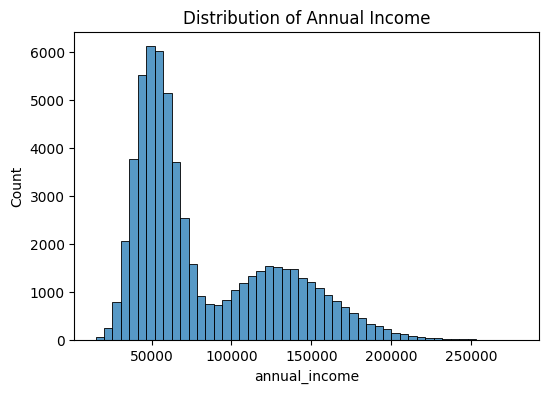

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["annual_income"], bins=50)
plt.title("Distribution of Annual Income")
plt.show()

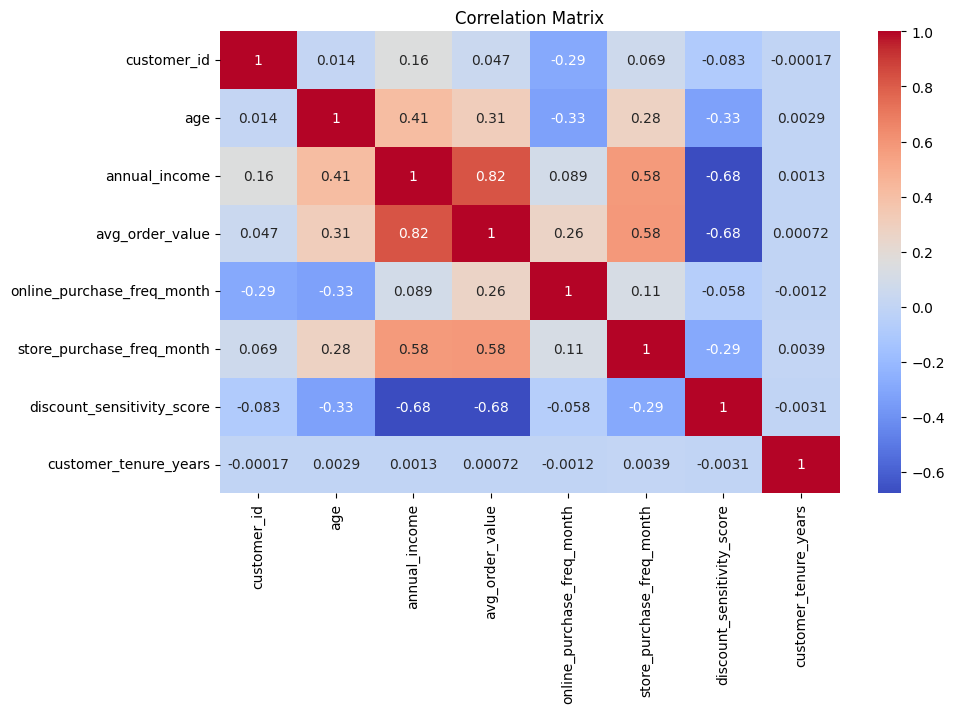

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

##**Feature Engineering**

In [ ]:
df["total_purchase_freq"] = (
    df["online_purchase_freq_month"] +
    df["store_purchase_freq_month"]
)

df["estimated_annual_spend"] = (
    df["avg_order_value"] *
    df["total_purchase_freq"] *
    12
)

In [ ]:
df_model = df.drop(columns=["customer_id", "favorite_category"])
df_model.columns

Index(['age', 'annual_income', 'avg_order_value', 'online_purchase_freq_month',
       'store_purchase_freq_month', 'discount_sensitivity_score',
       'customer_tenure_years', 'total_purchase_freq',
       'estimated_annual_spend'],
      dtype='object')

##**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(df_model)

In [ ]:
scaled_features

array([[ 1.29946887,  1.483333  ,  0.56237662, ..., -1.83161081,
         1.71964832,  1.16079092],
       [ 0.86813717, -0.17372234,  0.54156031, ...,  0.65319373,
        -0.27367605,  0.0131087 ],
       [ 1.40162638,  0.66798471,  1.59180197, ...,  1.12006723,
         0.3907654 ,  1.19858369],
       ...,
       [ 0.58436631,  1.50478147,  1.51309712, ..., -0.80967658,
         0.3907654 ,  1.13777065],
       [ 0.58436631,  0.72156407,  2.09217888, ..., -0.51917752,
         1.49816784,  2.80757508],
       [ 0.1870871 ,  1.08534193,  1.49943778, ...,  0.25375751,
        -0.27367605,  0.53119637]])

In [ ]:
scaled_df = pd.DataFrame(scaled_features, columns=df_model.columns)

scaled_df.describe()

,age,annual_income,avg_order_value,online_purchase_freq_month,store_purchase_freq_month,discount_sensitivity_score,customer_tenure_years,total_purchase_freq,estimated_annual_spend
count,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,60000.000000,6.000000e+04
mean,-2.861119e-16,1.515825e-17,-4.547474e-17,3.789561e-18,-4.547474e-17,-7.579123e-17,-2.203275e-16,0.000000,3.031649e-17
std,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008,1.000008e+00
min,-2.105781e+00,-1.528116e+00,-1.028173e+00,-1.537127e+00,-1.155166e+00,-1.547031e+00,-1.831611e+00,-1.824039,-8.595172e-01
25%,-6.982780e-01,-7.613485e-01,-7.734728e-01,-7.124780e-01,-7.182208e-01,-8.187916e-01,-7.163019e-01,-0.716637,-7.218398e-01
50%,6.222792e-02,-4.461052e-01,-5.305559e-01,1.121705e-01,-2.812760e-01,-9.055231e-02,-1.080414e-02,0.169285,-4.644760e-01
75%,7.205763e-01,8.012149e-01,8.457315e-01,6.619362e-01,5.926137e-01,4.556272e-01,6.856155e-01,0.612246,5.456068e-01
max,3.637741e+00,4.448581e+00,3.984870e+00,5.060062e+00,5.399007e+00,2.094166e+00,3.096498e+00,4.598895,7.106975e+00


##**Determining Optimal Clusters**

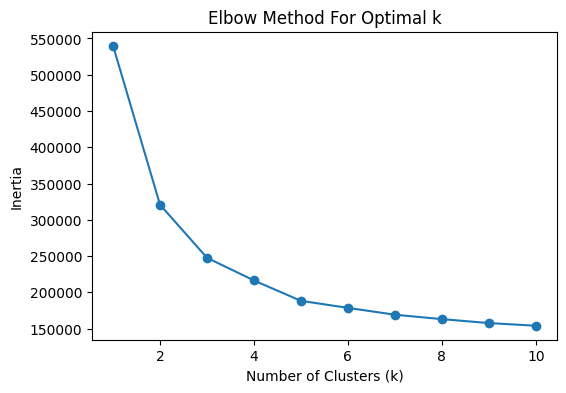

In [ ]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal k")
plt.show()

##**K Means Clustering**

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

df["cluster"] = clusters

In [ ]:
df.head()

,customer_id,age,annual_income,avg_order_value,online_purchase_freq_month,store_purchase_freq_month,discount_sensitivity_score,favorite_category,customer_tenure_years,total_purchase_freq,estimated_annual_spend,cluster
0,1,48.0,148195.54,748.94,11,5,0.18,Beauty,0.50,16,143796.48,4
1,2,44.2,74904.46,739.40,3,4,0.34,Home,5.29,7,62109.60,2
2,3,48.9,112132.92,1220.72,6,4,0.24,Fashion,6.19,10,146486.40,2
3,4,54.1,119000.16,1319.49,8,7,0.07,Sports,6.03,15,237508.20,4
4,5,43.6,120381.81,691.00,10,0,0.24,Fashion,2.27,10,82920.00,2


####**Cluster Profiling**

In [ ]:
cluster_profile = df.groupby("cluster").mean(numeric_only=True)

cluster_profile

,customer_id,age,annual_income,avg_order_value,online_purchase_freq_month,store_purchase_freq_month,discount_sensitivity_score,customer_tenure_years,total_purchase_freq,estimated_annual_spend
cluster,,,,,,,,,,
0,19257.147407,25.957147,45164.352747,249.939132,9.294367,1.009078,0.506606,4.033149,10.303445,30856.424365
1,42084.633545,39.668890,59583.465564,101.368311,1.124006,0.976731,0.408938,4.032802,2.100737,2783.118705
2,19539.888143,43.339262,127565.995895,932.144531,5.460012,3.459318,0.173855,4.028779,8.919330,97990.299491
3,31195.830009,35.058116,54685.832155,182.295334,4.959464,3.041090,0.887942,4.018942,8.000554,17486.962139
4,41156.224074,39.627945,143088.905305,1192.686758,7.899653,6.018570,0.129370,4.041648,13.918224,196739.286632


In [ ]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_features)

In [ ]:
pca_df = pd.DataFrame(pca_components, columns=["PCA1", "PCA2"])

pca_df["cluster"] = df["cluster"]

In [ ]:
pca_df.head()

,PCA1,PCA2,cluster
0,3.140373,0.503466,4
1,0.396702,-1.109158,2
2,2.352986,-0.887420,2
3,4.355546,-0.491089,4
4,0.993641,0.140723,2


In [ ]:
segment_names = {
    0: "Young Online Shoppers",
    1: "Low Spending Customers",
    2: "High Value Customers",
    3: "Low Engagement Customers",
    4: "Premium Customers"
}

df["customer_segment"] = df["cluster"].map(segment_names)

df.head()

,customer_id,age,annual_income,avg_order_value,online_purchase_freq_month,store_purchase_freq_month,discount_sensitivity_score,favorite_category,customer_tenure_years,total_purchase_freq,estimated_annual_spend,cluster,customer_segment
0,1,48.0,148195.54,748.94,11,5,0.18,Beauty,0.50,16,143796.48,4,Premium Customers
1,2,44.2,74904.46,739.40,3,4,0.34,Home,5.29,7,62109.60,2,High Value Customers
2,3,48.9,112132.92,1220.72,6,4,0.24,Fashion,6.19,10,146486.40,2,High Value Customers
3,4,54.1,119000.16,1319.49,8,7,0.07,Sports,6.03,15,237508.20,4,Premium Customers
4,5,43.6,120381.81,691.00,10,0,0.24,Fashion,2.27,10,82920.00,2,High Value Customers


####**Cluster Visualisation**

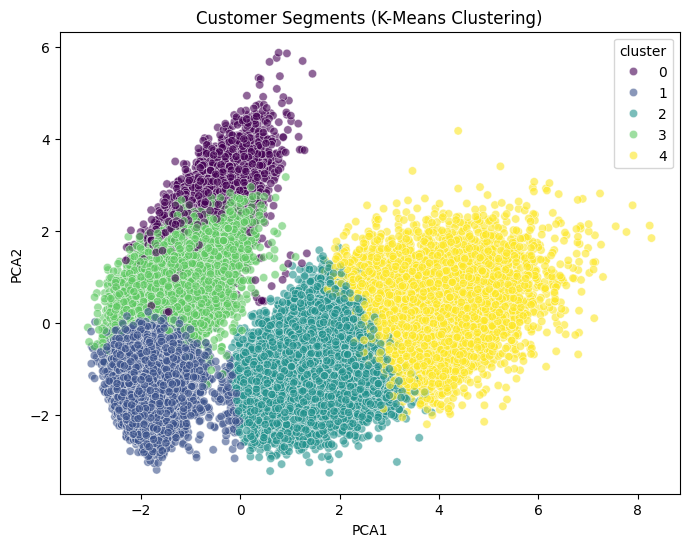

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="cluster",
    data=pca_df,
    palette="viridis",
    alpha=0.6
)

plt.title("Customer Segments (K-Means Clustering)")
plt.show()

In [ ]:
df["cluster"].value_counts()

,count
cluster,
1,13838
0,13439
2,12954
3,10830
4,8939


In [ ]:
revenue_by_cluster = df.groupby("cluster")["estimated_annual_spend"].sum()

revenue_by_cluster

,estimated_annual_spend
cluster,
0,4.146795e+08
1,3.851280e+07
2,1.269366e+09
3,1.893838e+08
4,1.758652e+09


In [ ]:
df["customer_segment"].unique()

array(['Premium Customers', 'High Value Customers',
       'Low Spending Customers', 'Young Online Shoppers',
       'Low Engagement Customers'], dtype=object)

In [ ]:
df.to_csv("customer_segmentation_final.csv", index=False)
from google.colab import files
files.download("customer_segmentation_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>